# Assignment 5: Generative Models in Practice

这份作业参考 `CS231n` 风格来组织：

- 每一题都先给背景
- 然后要求实现一个关键模块
- 最后回答几个 `Inline Question`

整份作业围绕这一讲的主线展开：

1. VAE 的核心组件
2. beta-VAE 的重建 / 规整权衡
3. diffusion 的前向加噪与反推公式
4. DDPM / DDIM 风格的 toy sampler
5. Flow Matching 与 Rectified Flow 的 2D 小实验


## 交付内容

建议提交：

1. 填完这份 notebook
2. 所有 `TODO` 都补全
3. 所有 `Inline Question` 都写出答案
4. 每一道大题都至少给出一组**可视化结果**
5. 不只是贴 loss 数字，要能从图里直观看出“做对了没有”

## 这份作业特别看重什么

这一讲是生成模型，所以只写代码、不看生成现象是不够的。  
从这一版开始，每一题都要带一个 **visual checkpoint**：

- VAE 要看到重建图、潜空间、插值图
- diffusion 要看到逐步加噪和反推效果
- DDPM / DDIM 要看到路径差异
- Flow Matching 要看到速度场和生成轨迹

## 评分建议

- Problem 1: 20 分
- Problem 2: 20 分
- Problem 3: 20 分
- Problem 4: 20 分
- Problem 5: 20 分

总分 100。


In [1]:
# Setup
import math
import random
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.datasets import make_moons

plt.style.use("seaborn-v0_8-whitegrid")
warnings.filterwarnings("ignore", message="FigureCanvasAgg is non-interactive")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
DATA_ROOT = Path.home() / "data"
print("device =", device)


device = cpu


In [2]:
# Helper functions used by multiple problems

def show_mnist_batch(dataset, n=10):
    fig, axes = plt.subplots(1, n, figsize=(1.5 * n, 2))
    for ax, idx in zip(axes, range(n)):
        image, label = dataset[idx]
        ax.imshow(image.squeeze(0), cmap="gray")
        ax.set_title(str(label))
        ax.axis("off")
    plt.tight_layout()
    plt.show()


def plot_points(points, title=""):
    points = np.asarray(points)
    plt.figure(figsize=(5, 5))
    plt.scatter(points[:, 0], points[:, 1], s=6)
    plt.title(title)
    plt.axis("equal")
    plt.show()


def plot_histories(histories, key, title):
    """把不同实验配置的同一种指标画在一张图里。"""
    plt.figure(figsize=(6, 4))
    for name, hist in histories.items():
        values = hist[key]
        plt.plot(range(1, len(values) + 1), values, marker='o', label=str(name))
    plt.title(title)
    plt.xlabel('epoch')
    plt.legend()
    plt.tight_layout()
    plt.show()


def compare_reconstructions(model_dict, loader, n=8):
    """把不同模型的重建结果放成并排图，便于直接比较。"""
    x, y = next(iter(loader))
    x = x[:n].to(device)
    model_names = list(model_dict.keys())

    fig, axes = plt.subplots(len(model_names) + 1, n, figsize=(1.5 * n, 1.8 * (len(model_names) + 1)))
    for i in range(n):
        axes[0, i].imshow(x[i].cpu().squeeze(0), cmap='gray')
        axes[0, i].set_title(f'orig {int(y[i])}', fontsize=9)
        axes[0, i].axis('off')

    for row, name in enumerate(model_names, start=1):
        model = model_dict[name]
        model.eval()
        with torch.no_grad():
            logits, _, _, _ = model(x.view(len(x), -1))
            recon = torch.sigmoid(logits).view(-1, 1, 28, 28).cpu()
        for i in range(n):
            axes[row, i].imshow(recon[i].squeeze(0), cmap='gray')
            axes[row, i].set_title(str(name), fontsize=9)
            axes[row, i].axis('off')
    plt.tight_layout()
    plt.show()


def latent_interpolation(model, dataset, label_a=1, label_b=7, n=8):
    """在潜空间中做线性插值，看图像是否平滑过渡。"""
    def pick_example(ds, label):
        for image, y in ds:
            if int(y) == label:
                return image
        raise ValueError(label)

    img_a = pick_example(dataset, label_a).unsqueeze(0).to(device)
    img_b = pick_example(dataset, label_b).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        mu_a, _ = model.encode(img_a.view(1, -1))
        mu_b, _ = model.encode(img_b.view(1, -1))
        ratios = torch.linspace(0, 1, n, device=device).unsqueeze(1)
        z_path = (1 - ratios) * mu_a + ratios * mu_b
        decoded = torch.sigmoid(model.decode(z_path)).view(-1, 1, 28, 28).cpu()

    fig, axes = plt.subplots(1, n, figsize=(1.6 * n, 2.2))
    for ax, image, ratio in zip(axes, decoded, torch.linspace(0, 1, n)):
        ax.imshow(image.squeeze(0), cmap='gray')
        ax.set_title(f'{ratio.item():.2f}', fontsize=9)
        ax.axis('off')
    plt.tight_layout()
    plt.show()


def plot_forward_noising(x0, noise, timesteps, alpha_bars):
    """画出同一张图像在不同时间步下的加噪效果。"""
    fig, axes = plt.subplots(1, len(timesteps), figsize=(2 * len(timesteps), 2.3))
    for ax, t in zip(axes, timesteps):
        t_tensor = torch.tensor([t], dtype=torch.long)
        x_t = q_sample(x0, t_tensor, noise, alpha_bars)
        ax.imshow(x_t.squeeze().cpu(), cmap='gray')
        ax.set_title(f't={t}', fontsize=9)
        ax.axis('off')
    plt.tight_layout()
    plt.show()


def compare_x0_recovery(x0, noise, timesteps, alpha_bars):
    """用真实噪声做 oracle 反推，检查 x_t -> x0_hat 是否正确。"""
    fig, axes = plt.subplots(2, len(timesteps), figsize=(2 * len(timesteps), 4.2))
    for col, t in enumerate(timesteps):
        t_tensor = torch.tensor([t], dtype=torch.long)
        x_t = q_sample(x0, t_tensor, noise, alpha_bars)
        x0_hat = predict_x0_from_eps(x_t, t_tensor, noise, alpha_bars)
        axes[0, col].imshow(x_t.squeeze().cpu(), cmap='gray')
        axes[0, col].set_title(f'x_t @ {t}', fontsize=9)
        axes[0, col].axis('off')
        axes[1, col].imshow(x0_hat.squeeze().cpu(), cmap='gray')
        axes[1, col].set_title('x0_hat', fontsize=9)
        axes[1, col].axis('off')
    plt.tight_layout()
    plt.show()


def plot_snapshot_rows(snapshot_rows, row_titles=None):
    """
    snapshot_rows: list of list[(title, points)]
    把不同方法的采样快照按行摆出来。
    """
    n_rows = len(snapshot_rows)
    n_cols = max(len(row) for row in snapshot_rows)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.8 * n_cols, 2.6 * n_rows))
    if n_rows == 1:
        axes = np.expand_dims(axes, 0)
    for r, row in enumerate(snapshot_rows):
        for c in range(n_cols):
            ax = axes[r, c]
            if c < len(row):
                title, points = row[c]
                pts = np.asarray(points)
                ax.scatter(pts[:, 0], pts[:, 1], s=5)
                ax.set_title(title, fontsize=9)
                ax.axis('equal')
            else:
                ax.axis('off')
        if row_titles is not None:
            axes[r, 0].set_ylabel(row_titles[r], rotation=90, fontsize=10)
    plt.tight_layout()
    plt.show()


def plot_vector_field_2d(model, t_value=0.5, xlim=(-3, 3), ylim=(-3, 3), grid_size=15):
    """把 2D 速度场画成 quiver 图。"""
    xs = np.linspace(*xlim, grid_size)
    ys = np.linspace(*ylim, grid_size)
    X, Y = np.meshgrid(xs, ys)
    grid = np.stack([X.ravel(), Y.ravel()], axis=1)
    grid_t = torch.tensor(grid, dtype=torch.float32, device=device)
    t = torch.full((len(grid_t),), float(t_value), device=device)
    model.eval()
    with torch.no_grad():
        V = model(grid_t, t).cpu().numpy()
    U = V[:, 0].reshape(X.shape)
    W = V[:, 1].reshape(Y.shape)
    plt.figure(figsize=(6, 6))
    plt.quiver(X, Y, U, W)
    plt.title(f'Estimated vector field at t={t_value:.2f}')
    plt.axis('equal')
    plt.show()


# Problem 1: Implement the Core of a VAE

这一题只做最核心的两件事：

1. 实现重参数化
2. 实现 VAE loss

目标是把下面这条主线真正落到代码里：

$$
q_\phi(z|x) = \mathcal N(\mu_\phi(x), \mathrm{diag}(\sigma_\phi^2(x)))
$$

$$
z = \mu + \sigma \odot \epsilon, \quad \epsilon \sim \mathcal N(0, I)
$$

$$
\mathcal L_{VAE} = -\mathbb E_{q_\phi(z|x)}[\log p_\theta(x|z)] + \beta D_{KL}(q_\phi(z|x)\|p(z))
$$


In [3]:
class TinyVAE(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
        )
        self.mu_head = nn.Linear(64, latent_dim)
        self.logvar_head = nn.Linear(64, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 28 * 28),
        )

    def encode(self, x):
        h = self.encoder(x)
        mu = self.mu_head(h)
        logvar = self.logvar_head(h)
        return mu, logvar

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = reparameterize(mu, logvar)
        logits = self.decode(z)
        return logits, mu, logvar, z


def reparameterize(mu, logvar):
    """
    TODO:
    用重参数化技巧从 N(mu, sigma^2) 里采样 z。

    输入:
    - mu: shape [B, D]
    - logvar: shape [B, D]

    输出:
    - z: shape [B, D]
    """
    raise NotImplementedError("Implement reparameterize")


def vae_loss(logits, x, mu, logvar, beta=1.0):
    """
    TODO:
    实现 VAE 的总损失、重建项和 KL 项。

    提示:
    - 重建项可以用 binary_cross_entropy_with_logits
    - KL 项直接用对角高斯的闭式公式
    """
    raise NotImplementedError("Implement vae_loss")


In [4]:
# Basic sanity check for Problem 1
x = torch.randn(4, 28 * 28)
mu = torch.randn(4, 2)
logvar = torch.randn(4, 2)

try:
    z = reparameterize(mu, logvar)
    assert z.shape == mu.shape
    print("reparameterize shape check passed")
except NotImplementedError:
    print("TODO: implement reparameterize")

logits = torch.randn(4, 28 * 28)
try:
    total, recon, kl = vae_loss(logits, x, mu, logvar, beta=1.0)
    print("vae_loss outputs:", total, recon, kl)
except NotImplementedError:
    print("TODO: implement vae_loss")


TODO: implement reparameterize
TODO: implement vae_loss


**Inline Question 1**

1. 为什么 VAE 通常输出 `logvar` 而不是直接输出 `sigma`？
2. 如果直接写 `z ~ N(mu, sigma^2)` 然后“硬采样”，反向传播会卡在哪里？
3. KL 项过大和过小，分别会带来什么问题？

$\color{blue}{\textit{Your Answer:}}$


# Problem 2: Train a beta-VAE and Inspect the Latent Space

这一题把 VAE 从“公式”推到“现象”。

你需要至少做 4 件事：

1. 训练一个小 VAE
2. 画出 `recon / KL / total loss`
3. 比较不同 `beta` 下的重建图和潜空间结构
4. 再做一组潜空间插值，检查“连续潜空间”是不是真的成立

这一题的 **visual checkpoint** 至少包括：

- 一张 loss 曲线图
- 一张不同 `beta` 的重建并排图
- 一张 latent scatter 图
- 一张 interpolation 图


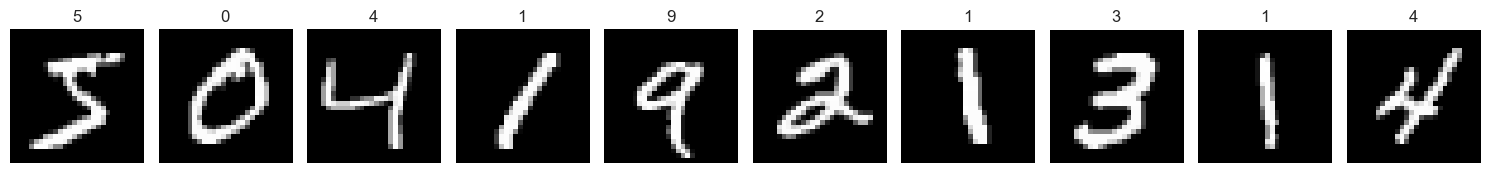

In [5]:
# Load a small MNIST subset
transform = transforms.ToTensor()
train_raw = datasets.MNIST(DATA_ROOT / "MNIST", train=True, download=True, transform=transform)
val_raw = datasets.MNIST(DATA_ROOT / "MNIST", train=False, download=True, transform=transform)

train_ds = Subset(train_raw, list(range(4096)))
val_ds = Subset(val_raw, list(range(1024)))
train_dl = DataLoader(train_ds, batch_size=128, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=256, shuffle=False)

show_mnist_batch(train_raw, n=10)


In [6]:
def run_epoch(loader, model, optimizer=None, beta=1.0):
    """
    TODO:
    实现一轮 VAE 训练 / 验证。

    返回一个 dict，包含:
    - loss
    - recon
    - kl
    """
    raise NotImplementedError("Implement run_epoch")


def train_beta_vae(beta=1.0, epochs=3, latent_dim=2):
    model = TinyVAE(latent_dim=latent_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    history = {"train_loss": [], "val_loss": [], "train_recon": [], "val_recon": [], "train_kl": [], "val_kl": []}

    for epoch in range(epochs):
        train_stats = run_epoch(train_dl, model, optimizer=optimizer, beta=beta)
        val_stats = run_epoch(val_dl, model, optimizer=None, beta=beta)
        history["train_loss"].append(train_stats["loss"])
        history["val_loss"].append(val_stats["loss"])
        history["train_recon"].append(train_stats["recon"])
        history["val_recon"].append(val_stats["recon"])
        history["train_kl"].append(train_stats["kl"])
        history["val_kl"].append(val_stats["kl"])
        print(f"beta={beta}, epoch={epoch+1}, val_loss={val_stats['loss']:.2f}")
    return model, history


In [7]:
# TODO:
# 把这一题做成“结果一眼能看出来”的版本。
# 建议至少完成下面这些可视化：
#
# 1. 先跑 beta=0.1, 1.0, 4.0 三组实验
# 2. 画三种 beta 的 val_loss / val_recon / val_kl 曲线
# 3. 用 compare_reconstructions(...) 把三组重建图并排画出来
# 4. 至少选两组 beta，画 latent scatter 图
# 5. 至少选一组 beta，做 latent_interpolation(...)
#
# 一个推荐骨架：
#
# models = {}
# histories = {}
# for beta in [0.1, 1.0, 4.0]:
#     models[beta], histories[beta] = train_beta_vae(beta=beta, epochs=3)
#
# plot_histories(histories, 'val_loss', 'Validation Total Loss')
# plot_histories(histories, 'val_recon', 'Validation Recon Loss')
# plot_histories(histories, 'val_kl', 'Validation KL Loss')
# compare_reconstructions(models, val_dl)
# visualize_latent_means(models[0.1], val_dl)
# visualize_latent_means(models[4.0], val_dl)
# latent_interpolation(models[1.0], val_raw)


In [8]:
def visualize_reconstruction(model, loader, n=8):
    model.eval()
    x, y = next(iter(loader))
    x = x[:n].to(device)
    with torch.no_grad():
        logits, mu, logvar, z = model(x.view(len(x), -1))
        recon = torch.sigmoid(logits).view(-1, 1, 28, 28).cpu()

    fig, axes = plt.subplots(2, n, figsize=(1.5 * n, 3))
    for i in range(n):
        axes[0, i].imshow(x[i].cpu().squeeze(0), cmap="gray")
        axes[0, i].axis("off")
        axes[1, i].imshow(recon[i].squeeze(0), cmap="gray")
        axes[1, i].axis("off")
    plt.tight_layout()
    plt.show()


def visualize_latent_means(model, loader):
    model.eval()
    all_mu, all_labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device).view(len(x), -1)
            mu, _ = model.encode(x)
            all_mu.append(mu.cpu())
            all_labels.append(y)
    all_mu = torch.cat(all_mu).numpy()
    all_labels = torch.cat(all_labels).numpy()
    plt.figure(figsize=(6, 5))
    scatter = plt.scatter(all_mu[:, 0], all_mu[:, 1], c=all_labels, s=8, cmap="tab10", alpha=0.8)
    plt.colorbar(scatter)
    plt.title("Latent means")
    plt.show()


**Inline Question 2**

1. 当 `beta` 从 `0.1` 增大到 `4.0` 时，重建图通常会怎么变？
2. 什么情况下可以怀疑出现了 `posterior collapse`？
3. 如果想让潜空间更规整，但又不想重建掉得太厉害，可以尝试哪些办法？
4. 在你画出来的 4 类图里，哪一类最能直接说明“这个 VAE 的潜空间是不是真的连续可走”？为什么？

$\color{blue}{\textit{Your Answer:}}$


# Problem 3: Implement the Forward Diffusion Process

这一题把 diffusion 里最关键的前向公式写出来，并用代码验证：

$$
x_t = \sqrt{\bar\alpha_t} x_0 + \sqrt{1-\bar\alpha_t} \epsilon
$$

以及从 `x_t` 和预测噪声 `\hat\epsilon` 反推出 `\hat x_0`：

$$
\hat x_0 = \frac{x_t - \sqrt{1-\bar\alpha_t}\, \hat\epsilon}{\sqrt{\bar\alpha_t}}
$$


In [9]:
def make_beta_schedule(T, beta_start=1e-4, beta_end=2e-2):
    return torch.linspace(beta_start, beta_end, T)


def prepare_diffusion_constants(T=1000):
    betas = make_beta_schedule(T)
    alphas = 1.0 - betas
    alpha_bars = torch.cumprod(alphas, dim=0)
    return betas, alphas, alpha_bars


def q_sample(x0, t, noise, alpha_bars):
    """
    TODO:
    实现 q(x_t | x_0) 的闭式采样。

    输入:
    - x0: [B, ...]
    - t: [B]
    - noise: same shape as x0
    - alpha_bars: [T]
    """
    raise NotImplementedError("Implement q_sample")


def predict_x0_from_eps(x_t, t, eps_hat, alpha_bars):
    """
    TODO:
    根据 x_t 和噪声预测 eps_hat 反推出 x0_hat。
    """
    raise NotImplementedError("Implement predict_x0_from_eps")


In [10]:
# Visualization for Problem 3
betas, alphas, alpha_bars = prepare_diffusion_constants(T=1000)
image0, label0 = train_raw[0]
x0 = image0.unsqueeze(0)
noise = torch.randn_like(x0)
timesteps_to_show = [0, 50, 150, 300, 600, 999]

# TODO:
# 这一题不要只写公式，要把现象画出来。
# 至少完成两组图：
#
# 1. forward noising 图：
#    plot_forward_noising(x0, noise, timesteps_to_show, alpha_bars)
#
# 2. x_t -> x0_hat 恢复图：
#    用真实 noise 当 oracle，检查 predict_x0_from_eps 是否写对。
#    compare_x0_recovery(x0, noise, [50, 300, 600, 999], alpha_bars)
#
# 如果想再多做一步，可以把不同 t 下的 mean absolute error 也打印出来。


**Inline Question 3**

1. 为什么 diffusion 里常见的监督目标是“预测噪声”，而不是直接一步输出最终图像？
2. `t` 越大时，这个预测任务通常会更难还是更容易？为什么？
3. 如果 `\bar\alpha_t` 非常小，`x_t` 会更接近什么？

$\color{blue}{\textit{Your Answer:}}$


# Problem 4: Build a Toy Sampler and Compare DDPM vs DDIM Style Updates

这一题把“训练一个去噪器”和“选择回去的路线”放在一起看。

这里不直接复用课上的 2D 数据准备代码，而是自己构造一个双月形分布。  
这样更适合作业场景：可以把“数据构造”和“生成路径”分开看。

这一题最重要的不是 loss 数字，而是**两种采样路线到底画出来有什么差别**。

这一题的 **visual checkpoint** 至少包括：

- 一张 toy training loss 图
- 一张 DDPM vs DDIM 的快照并排图
- 至少一张最终采样点云和目标分布的对比图


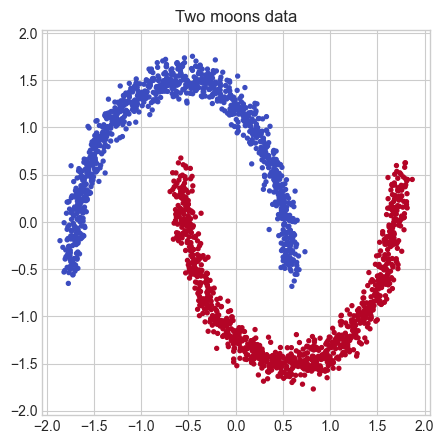

In [11]:
# 自己构造一个双月形二维分布，不直接复用课上的示例代码

def sample_double_moons(n_samples=2048, noise_std=0.05, seed=SEED):
    rng = np.random.default_rng(seed)
    half = n_samples // 2

    # 上半月：以原点附近为圆心的一段弧
    theta_top = rng.uniform(0.0, np.pi, size=half)
    top = np.stack([np.cos(theta_top), np.sin(theta_top)], axis=1)

    # 下半月：平移后再翻转，形成另一条月牙
    theta_bottom = rng.uniform(0.0, np.pi, size=n_samples - half)
    bottom = np.stack([1.0 - np.cos(theta_bottom), 0.35 - np.sin(theta_bottom)], axis=1)

    x = np.concatenate([top, bottom], axis=0)
    y = np.concatenate([
        np.zeros(half, dtype=np.int64),
        np.ones(n_samples - half, dtype=np.int64)
    ], axis=0)

    x += rng.normal(scale=noise_std, size=x.shape)
    x = (x - x.mean(axis=0, keepdims=True)) / x.std(axis=0, keepdims=True)
    return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.long)


toy_x, toy_y = sample_double_moons(n_samples=2048, noise_std=0.06, seed=SEED)

plt.figure(figsize=(5, 5))
plt.scatter(toy_x[:, 0], toy_x[:, 1], c=toy_y, s=8, cmap='coolwarm')
plt.axis('equal')
plt.title('Custom double-moons data')
plt.show()


In [12]:
# 不沿用课上的正弦时间步编码，改成更直接的标量时间特征

def make_time_features(timesteps, total_steps, include_trig=True):
    """
    把离散时间步编码成一组简单特征。

    这里故意采用更朴素的设计：
    - 归一化时间 t
    - t^2
    - t^3
    - sin(pi t), cos(pi t)

    这样既保留时间信息，也避免和课上的编码实现重合。
    """
    tau = timesteps.float().unsqueeze(1) / max(total_steps - 1, 1)
    feats = [tau, tau ** 2, tau ** 3]
    if include_trig:
        feats += [torch.sin(math.pi * tau), torch.cos(math.pi * tau)]
    return torch.cat(feats, dim=1)


class ToyDenoiser(nn.Module):
    def __init__(self, total_steps=100, time_dim=5):
        super().__init__()
        self.total_steps = total_steps
        self.time_dim = time_dim
        self.net = nn.Sequential(
            nn.Linear(2 + time_dim, 128),
            nn.SiLU(),
            nn.Linear(128, 128),
            nn.SiLU(),
            nn.Linear(128, 64),
            nn.SiLU(),
            nn.Linear(64, 2),
        )

    def forward(self, x_t, t):
        t_feat = make_time_features(t, total_steps=self.total_steps)
        return self.net(torch.cat([x_t, t_feat], dim=1))


In [13]:
def toy_train_step(model, optimizer, x0, alphas, alpha_bars):
    """
    TODO:
    实现一个 toy diffusion 训练 step。

    提示:
    1. 随机采 t
    2. 随机采 noise
    3. 构造 x_t
    4. 预测 noise
    5. 用 MSE 训练
    """
    raise NotImplementedError("Implement toy_train_step")


def ddpm_like_step(x_t, eps_hat, t, alphas, alpha_bars):
    """
    TODO:
    实现一个简化版 DDPM 风格采样步。
    """
    raise NotImplementedError("Implement ddpm_like_step")


def ddim_like_step(x_t, eps_hat, t, alpha_bars):
    """
    TODO:
    实现一个简化版 DDIM 风格采样步。
    把它写成 eta=0 的确定性更新也可以。
    """
    raise NotImplementedError("Implement ddim_like_step")


In [14]:
# 训练一个 toy denoiser，然后分别用 DDPM 风格和 DDIM 风格更新做采样比较
T_toy = 80
betas_toy, alphas_toy, alpha_bars_toy = prepare_diffusion_constants(T=T_toy)
toy_model = ToyDenoiser(total_steps=T_toy).to(device)
toy_opt = torch.optim.Adam(toy_model.parameters(), lr=1e-3)

toy_losses = []
for step in range(400):
    idx = torch.randint(0, len(toy_x), (256,))
    x0 = toy_x[idx].to(device)
    loss = toy_train_step(toy_model, toy_opt, x0, alphas_toy, alpha_bars_toy)
    toy_losses.append(loss)

# 1) 训练曲线
plt.figure(figsize=(6, 3))
plt.plot(toy_losses)
plt.title('Toy diffusion training loss')
plt.xlabel('step')
plt.ylabel('MSE')
plt.show()


def sample_toy(model, mode='ddpm', n_samples=512, T=80):
    model.eval()
    x_t = torch.randn(n_samples, 2, device=device)
    snapshots = [('target', toy_x.numpy())]
    keep_steps = [79, 59, 39, 19, 0]

    for t in reversed(range(T)):
        t_batch = torch.full((len(x_t),), t, device=device, dtype=torch.long)
        with torch.no_grad():
            eps_hat = model(x_t, t_batch)

        if mode == 'ddpm':
            x_t = ddpm_like_step(x_t, eps_hat, t, alphas_toy, alpha_bars_toy)
        elif mode == 'ddim':
            x_t = ddim_like_step(x_t, eps_hat, t, alpha_bars_toy)
        else:
            raise ValueError(mode)

        if t in keep_steps:
            snapshots.append((f't={t}', x_t.detach().cpu().numpy()))
    return snapshots

snap_ddpm = sample_toy(toy_model, mode='ddpm', n_samples=512, T=T_toy)
snap_ddim = sample_toy(toy_model, mode='ddim', n_samples=512, T=T_toy)

plot_snapshot_rows(
    [snap_ddpm, snap_ddim],
    row_titles=['DDPM-style', 'DDIM-style'],
    colors=['tab:orange', 'tab:green']
)

fig, axes = plt.subplots(1, 3, figsize=(10, 3.2))
axes[0].scatter(toy_x[:, 0], toy_x[:, 1], s=5, c='tab:blue')
axes[0].set_title('target data')
axes[0].axis('equal')
axes[1].scatter(snap_ddpm[-1][1][:, 0], snap_ddpm[-1][1][:, 1], s=5, c='tab:orange')
axes[1].set_title('DDPM final')
axes[1].axis('equal')
axes[2].scatter(snap_ddim[-1][1][:, 0], snap_ddim[-1][1][:, 1], s=5, c='tab:green')
axes[2].set_title('DDIM final')
axes[2].axis('equal')
plt.tight_layout()
plt.show()


**Inline Question 4**

1. 在这个 toy 例子里，DDPM 风格和 DDIM 风格更新最大的区别是什么？
2. 为什么很多时候会说 DDIM 更像“同一个模型上的更快路线”？
3. 如果采样步数很少，哪种路径设计通常更关键：训练目标，还是采样更新公式？

$\color{blue}{\textit{Your Answer:}}$


# Problem 5: Implement a Toy Flow Matching Model

这一题把视角从“去噪”切到“速度场”。

我们继续使用前面自己构造的双月形分布做一个很小的 Flow Matching 实验：

- 起点分布：标准高斯
- 终点分布：自定义双月数据
- 路径：线性插值
- 目标速度：`x_1 - x_0`

核心公式是：

$$
\frac{d x_t}{dt} = v_\theta(x_t, t)
$$

$$
x_t = (1-t)x_0 + t x_1
$$

$$
\mathcal L_{FM} = \mathbb E\left[\|v_\theta(x_t, t) - (x_1 - x_0)\|^2\right]
$$

这一题的 **visual checkpoint** 至少包括：

- 一张训练 loss 图
- 一张 `t=0.5` 左右的 2D 向量场图
- 一张 Euler 积分的中间轨迹 / 快照图
- 一张最终生成点云 vs 目标点云的对比图


In [15]:
class ToyFlowModel(nn.Module):
    def __init__(self, time_dim=5):
        super().__init__()
        self.time_dim = time_dim
        self.net = nn.Sequential(
            nn.Linear(2 + time_dim, 128),
            nn.SiLU(),
            nn.Linear(128, 128),
            nn.SiLU(),
            nn.Linear(128, 64),
            nn.SiLU(),
            nn.Linear(64, 2),
        )

    def forward(self, x_t, t):
        # Flow Matching 的时间是连续的 [0, 1]，因此直接拼接多项式+三角特征
        tau = t.float().unsqueeze(1)
        t_feat = torch.cat([
            tau,
            tau ** 2,
            tau ** 3,
            torch.sin(math.pi * tau),
            torch.cos(math.pi * tau),
        ], dim=1)
        return self.net(torch.cat([x_t, t_feat], dim=1))


def sample_flow_matching_batch(x1):
    """
    给定终点样本 x1，构造 Flow Matching 所需的训练三元组。

    线性插值路径：
        x_t = (1 - t) x0 + t x1

    在线性插值下，
        d x_t / dt = x1 - x0
    因此目标速度是常数向量 target_velocity = x1 - x0。
    """
    x0 = torch.randn_like(x1)
    t = torch.rand(len(x1), device=x1.device)
    x_t = (1.0 - t.unsqueeze(1)) * x0 + t.unsqueeze(1) * x1
    target_velocity = x1 - x0
    return x0, t, x_t, target_velocity


def flow_matching_loss(model, x_t, t, target_velocity):
    pred_velocity = model(x_t, t)
    loss = F.mse_loss(pred_velocity, target_velocity)
    return loss


def euler_integrate_flow(model, n_samples=512, n_steps=50):
    model.eval()
    dt = 1.0 / n_steps
    x = torch.randn(n_samples, 2, device=device)
    snapshots = [(0.0, x.detach().cpu().clone())]

    for step in range(n_steps):
        t_scalar = step / n_steps
        t = torch.full((n_samples,), t_scalar, device=device)
        with torch.no_grad():
            v = model(x, t)
        x = x + dt * v
        if step + 1 in [1, 10, 20, 35, 50]:
            snapshots.append(((step + 1) / n_steps, x.detach().cpu().clone()))
    return snapshots


In [16]:
# 训练一个 Toy Flow Matching 模型，并把“速度场”和“生成轨迹”都画出来
flow_model = ToyFlowModel().to(device)
flow_opt = torch.optim.Adam(flow_model.parameters(), lr=1e-3)

flow_losses = []
for step in range(400):
    idx = torch.randint(0, len(toy_x), (256,))
    x1 = toy_x[idx].to(device)
    x0, t, x_t, target_velocity = sample_flow_matching_batch(x1)
    loss = flow_matching_loss(flow_model, x_t, t, target_velocity)

    flow_opt.zero_grad()
    loss.backward()
    flow_opt.step()
    flow_losses.append(float(loss.item()))

plt.figure(figsize=(6, 3))
plt.plot(flow_losses)
plt.title('Toy Flow Matching training loss')
plt.xlabel('step')
plt.ylabel('MSE')
plt.show()

plot_vector_field_2d(flow_model, t_value=0.2)
plot_vector_field_2d(flow_model, t_value=0.5)
plot_vector_field_2d(flow_model, t_value=0.8)

snapshots = euler_integrate_flow(flow_model, n_samples=512, n_steps=50)
row = [(f't={time_value:.2f}', pts.numpy()) for time_value, pts in snapshots]
plot_snapshot_rows([row], row_titles=['Flow Matching'], colors=['tab:purple'])

final_pts = snapshots[-1][1].numpy()
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
axes[0].scatter(toy_x[:, 0], toy_x[:, 1], s=5, c='tab:blue')
axes[0].set_title('target data')
axes[0].axis('equal')
axes[1].scatter(final_pts[:, 0], final_pts[:, 1], s=5, c='tab:purple')
axes[1].set_title('flow matching final')
axes[1].axis('equal')
plt.tight_layout()
plt.show()


**Inline Question 5**

1. 在线性插值路径下，为什么目标速度 `x_1 - x_0` 是常数？
2. 为什么很多人会觉得 Flow Matching 比 diffusion 更像“学一张地图上的方向场”？
3. Rectified Flow 和这道题的 toy Flow Matching 有什么相似处？又有什么关键差别？
4. 如果想让路径更直、更适合少步数采样，你会优先改哪一部分？
5. 从你画出来的向量场和积分轨迹来看，模型最容易出什么问题：方向不稳、路径弯曲、还是终点分布不对齐？

$\color{blue}{\textit{Your Answer:}}$


# Optional Extra Credit: From Flow Matching to Rectified Flow

可选加分题，不要求必须完成。

试着把 Problem 5 再往前推一步：

1. 先训练一个 toy flow model
2. 用它生成一批新的 `(x_0, x_1)` 对
3. 再基于这些新对重新训练一次
4. 观察轨迹有没有变得更直

如果愿意做这一题，请额外回答：

- 这个过程为什么会让人联想到 `reflow`？
- “路径更直”在数值求解时到底意味着什么？


# 提交前自查

在提交之前，建议确认：

- 所有 `TODO` 都已经补全
- 所有 `Inline Question` 都已经回答
- 至少有一组 VAE 重建图
- 至少有一组 latent scatter 图
- 至少有一组 latent interpolation 图
- 至少有一组 diffusion 加噪图
- 至少有一组 `x_t -> x0_hat` 恢复图
- 至少有一组 DDPM / DDIM toy 采样快照对比图
- 至少有一张 Flow Matching 向量场图
- 至少有一组 Flow Matching 最终生成结果对比图

如果只给出 loss 曲线，而没有关键可视化，这份作业还不算完成。
